#  Medical Insurance Cost Prediction
## Notebook 3 — Modeling

---
**Input :** `data/processed/`  
**Output:** `models/` — trained models + results table  
**Target:** `log_cost` → evaluated on original scale via `expm1`


<a id='1'></a>
## 1. Setup & Imports

In [1]:
pip install optuna

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib
import os
import time

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

RANDOM_STATE = 55
N_TRIALS     = 50
CV_FOLDS     = 5

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)


<a id='2'></a>
## 2. Load Processed Data

In [3]:
# Unscaled — tree-based models
X_train = pd.read_csv('//content/X_train.csv')
X_test  = pd.read_csv('/content/X_test.csv')

# Scaled — linear models & SVR
X_train_scaled = pd.read_csv('/content/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('/content/X_test_scaled.csv')

# Targets
y_train     = pd.read_csv('/content/y_train.csv').squeeze()
y_test      = pd.read_csv('/content/y_test.csv').squeeze()
y_train_raw = pd.read_csv('/content/y_train_raw.csv').squeeze()
y_test_raw  = pd.read_csv('/content/y_test_raw.csv').squeeze()

print(f'Train : {X_train.shape[0]:,} rows | {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} rows')
print(f'Features: {X_train.columns.tolist()}')

Train : 80,000 rows | 8 features
Test  : 20,000 rows
Features: ['age', 'bmi', 'visits_last_year', 'provider_quality', 'risk_score', 'chronic_count', 'disease_burden', 'had_major_procedure']


<a id='3'></a>
## 3. Evaluation Metrics

> All models are trained on `log_cost` but evaluated on the **original scale** using `expm1`  
> so that metrics are interpretable in real dollar terms.

In [4]:
def evaluate(model, X_tr, y_tr, X_te, y_te, y_te_raw, model_name, fit_time=None):
    """
    Evaluate a model on log-scale predictions, then convert back to original scale.
    Returns a dict of metrics.
    """
    # Predictions on log scale
    y_pred_log = model.predict(X_te)

    # Convert back to original scale
    y_pred = np.expm1(y_pred_log)
    y_true = y_te_raw.values

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    # 5-Fold CV on log scale
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf,
                                scoring='r2', n_jobs=-1)

    result = {
        'Model'      : model_name,
        'R2'         : round(r2, 4),
        'RMSE'       : round(rmse, 2),
        'MAE'        : round(mae, 2),
        'MAPE (%)'   : round(mape, 2),
        'CV R2 Mean' : round(cv_scores.mean(), 4),
        'CV R2 Std'  : round(cv_scores.std(), 4),
        'Fit Time(s)': round(fit_time, 1) if fit_time else None
    }

    print(f'  R²        : {r2:.4f}')
    print(f'  RMSE      : {rmse:,.2f}')
    print(f'  MAE       : {mae:,.2f}')
    print(f'  MAPE      : {mape:.2f}%')
    print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    return result

results = []  # All model results will accumulate here.
print(' Evaluation function defined.')

 Evaluation function defined.


<a id='4'></a>
## 4. Baseline — Linear Regression

> No hyperparameter tuning — serves as the baseline reference point.

In [5]:
print('── Linear Regression ─────────────────────────────')

t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
fit_time = time.time() - t0

res = evaluate(lr, X_train_scaled, y_train,
               X_test_scaled, y_test, y_test_raw,
               'Linear Regression', fit_time)
results.append(res)
joblib.dump(lr, '../models/linear_regression.pkl')


── Linear Regression ─────────────────────────────
  R²        : 0.0582
  RMSE      : 3,027.59
  MAE       : 1,701.04
  MAPE      : 75.11%
  CV R² (5-fold): 0.1751 ± 0.0030


['../models/linear_regression.pkl']

<a id='5'></a>
## 5. Ridge & Lasso — Optuna Tuning

> Regularized linear models. Optuna searches for the optimal `alpha`.

In [6]:
print('── Ridge Regression ──────────────────────────────')

def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100, log=True)
    model = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_ridge = optuna.create_study(direction='maximize')
study_ridge.optimize(ridge_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_ridge = Ridge(**study_ridge.best_params, random_state=RANDOM_STATE)
t0 = time.time()
best_ridge.fit(X_train_scaled, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_ridge.best_params}')
res = evaluate(best_ridge, X_train_scaled, y_train,
               X_test_scaled, y_test, y_test_raw,
               'Ridge Regression', fit_time)
results.append(res)
joblib.dump(best_ridge, '../models/ridge.pkl')

── Ridge Regression ──────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'alpha': 13.304943165600418}
  R²        : 0.0582
  RMSE      : 3,027.64
  MAE       : 1,701.04
  MAPE      : 75.11%
  CV R² (5-fold): 0.1751 ± 0.0030


['../models/ridge.pkl']

In [7]:
print('── Lasso Regression ──────────────────────────────')

def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10, log=True)
    model = Lasso(alpha=alpha, random_state=RANDOM_STATE, max_iter=5000)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_lasso = optuna.create_study(direction='maximize')
study_lasso.optimize(lasso_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lasso = Lasso(**study_lasso.best_params, random_state=RANDOM_STATE, max_iter=5000)
t0 = time.time()
best_lasso.fit(X_train_scaled, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_lasso.best_params}')
res = evaluate(best_lasso, X_train_scaled, y_train,
               X_test_scaled, y_test, y_test_raw,
               'Lasso Regression', fit_time)
results.append(res)
joblib.dump(best_lasso, '../models/lasso.pkl')

── Lasso Regression ──────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'alpha': 0.0003497818013893732}
  R²        : 0.0578
  RMSE      : 3,028.17
  MAE       : 1,701.02
  MAPE      : 75.10%
  CV R² (5-fold): 0.1751 ± 0.0030


['../models/lasso.pkl']

<a id='6'></a>
## 6. Decision Tree — Optuna Tuning

In [8]:
print('── Decision Tree ─────────────────────────────────')

def dt_objective(trial):
    params = {
        'max_depth'       : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(dt_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_dt = DecisionTreeRegressor(**study_dt.best_params, random_state=RANDOM_STATE)
t0 = time.time()
best_dt.fit(X_train, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_dt.best_params}')
res = evaluate(best_dt, X_train, y_train,
               X_test, y_test, y_test_raw,
               'Decision Tree', fit_time)
results.append(res)
joblib.dump(best_dt, '../models/decision_tree.pkl')

── Decision Tree ─────────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None}
  R²        : 0.0545
  RMSE      : 3,033.52
  MAE       : 1,705.26
  MAPE      : 75.37%
  CV R² (5-fold): 0.1695 ± 0.0044


['../models/decision_tree.pkl']

<a id='7'></a>
## 7. Random Forest — Optuna Tuning

In [9]:
print('── Random Forest ─────────────────────────────────')

def rf_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_rf = RandomForestRegressor(**study_rf.best_params,
                                random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
best_rf.fit(X_train, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_rf.best_params}')
res = evaluate(best_rf, X_train, y_train,
               X_test, y_test, y_test_raw,
               'Random Forest', fit_time)
results.append(res)
joblib.dump(best_rf, '../models/random_forest.pkl')

── Random Forest ─────────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 355, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2'}
  R²        : 0.0586
  RMSE      : 3,027.00
  MAE       : 1,695.84
  MAPE      : 74.84%
  CV R² (5-fold): 0.1786 ± 0.0032


['../models/random_forest.pkl']

<a id='8'></a>
## 8. Gradient Boosting — Optuna Tuning

In [10]:
print('── Gradient Boosting ─────────────────────────────')

def gbm_objective(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'     : trial.suggest_int('max_depth', 3, 10),
        'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }
    model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_gbm = optuna.create_study(direction='maximize')
study_gbm.optimize(gbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_gbm = GradientBoostingRegressor(**study_gbm.best_params, random_state=RANDOM_STATE)
t0 = time.time()
best_gbm.fit(X_train, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_gbm.best_params}')
res = evaluate(best_gbm, X_train, y_train,
               X_test, y_test, y_test_raw,
               'Gradient Boosting', fit_time)
results.append(res)
joblib.dump(best_gbm, '../models/gradient_boosting.pkl')

── Gradient Boosting ─────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 420, 'learning_rate': 0.036832237812146076, 'max_depth': 3, 'subsample': 0.7294385856989197, 'min_samples_split': 5}
  R²        : 0.0636
  RMSE      : 3,018.94
  MAE       : 1,693.37
  MAPE      : 74.68%
  CV R² (5-fold): 0.1811 ± 0.0033


['../models/gradient_boosting.pkl']

<a id='9'></a>
## 9. XGBoost — Optuna Tuning

In [11]:
print('── XGBoost ───────────────────────────────────────')

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
    }
    model = XGBRegressor(**params, random_state=RANDOM_STATE,
                         n_jobs=-1, verbosity=0)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb = XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE,
                         n_jobs=-1, verbosity=0)
t0 = time.time()
best_xgb.fit(X_train, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_xgb.best_params}')
res = evaluate(best_xgb, X_train, y_train,
               X_test, y_test, y_test_raw,
               'XGBoost', fit_time)
results.append(res)
joblib.dump(best_xgb, '../models/xgboost.pkl')

── XGBoost ───────────────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 185, 'learning_rate': 0.11595986117217302, 'max_depth': 3, 'subsample': 0.9006785518998487, 'colsample_bytree': 0.7742810897518803, 'reg_alpha': 0.0002033842333897975, 'reg_lambda': 6.304151514566757, 'min_child_weight': 5}
  R²        : 0.0634
  RMSE      : 3,019.27
  MAE       : 1,693.53
  MAPE      : 74.71%
  CV R² (5-fold): 0.1811 ± 0.0030


['../models/xgboost.pkl']

<a id='10'></a>
## 10. LightGBM — Optuna Tuning

In [12]:
print('── LightGBM ──────────────────────────────────────')

def lgbm_objective(trial):
    params = {
        'n_estimators'   : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'  : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'      : trial.suggest_int('max_depth', 3, 12),
        'num_leaves'     : trial.suggest_int('num_leaves', 20, 150),
        'subsample'      : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'      : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'     : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    model = LGBMRegressor(**params, random_state=RANDOM_STATE,
                          n_jobs=-1, verbose=-1)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE,
                           n_jobs=-1, verbose=-1)
t0 = time.time()
best_lgbm.fit(X_train, y_train)
fit_time = time.time() - t0

print(f'Best params: {study_lgbm.best_params}')
res = evaluate(best_lgbm, X_train, y_train,
               X_test, y_test, y_test_raw,
               'LightGBM', fit_time)
results.append(res)
joblib.dump(best_lgbm, '../models/lightgbm.pkl')

── LightGBM ──────────────────────────────────────


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 124, 'learning_rate': 0.11744941618118807, 'max_depth': 3, 'num_leaves': 109, 'subsample': 0.627058516364689, 'colsample_bytree': 0.628523977119694, 'reg_alpha': 0.6174878979577224, 'reg_lambda': 3.5747884194553663, 'min_child_samples': 50}
  R²        : 0.0608
  RMSE      : 3,023.43
  MAE       : 1,694.68
  MAPE      : 74.77%
  CV R² (5-fold): 0.1805 ± 0.0032


['../models/lightgbm.pkl']

<a id='12'></a>
## 11. Results Summary

In [13]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

print('── Model Comparison ──────────────────────────────')
display(
    results_df.style
    .background_gradient(subset=['R2', 'CV R2 Mean'], cmap='Greens')
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE (%)'], cmap='Reds_r')
    .format({'R2': '{:.4f}', 'CV R2 Mean': '{:.4f}',
             'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'MAPE (%)': '{:.2f}'})
)

── Model Comparison ──────────────────────────────


,Model,R2,RMSE,MAE,MAPE (%),CV R2 Mean,CV R2 Std,Fit Time(s)
1,Gradient Boosting,0.0636,"3,018.94","1,693.37",74.68,0.1811,0.003300,28.400000
2,XGBoost,0.0634,"3,019.27","1,693.53",74.71,0.1811,0.003000,0.700000
3,LightGBM,0.0608,"3,023.43","1,694.68",74.77,0.1805,0.003200,0.400000
4,Random Forest,0.0586,"3,027.00","1,695.84",74.84,0.1786,0.003200,17.700000
5,Ridge Regression,0.0582,"3,027.64","1,701.04",75.11,0.1751,0.003000,0.000000
6,Linear Regression,0.0582,"3,027.59","1,701.04",75.11,0.1751,0.003000,0.000000
7,Lasso Regression,0.0578,"3,028.17","1,701.02",75.10,0.1751,0.003000,0.100000
8,Decision Tree,0.0545,"3,033.52","1,705.26",75.37,0.1695,0.004400,0.200000


In [14]:
# Best model
best_row = results_df.iloc[0]
print(f'Best model : {best_row["Model"]}')
print(f'R²         : {best_row["R2"]}')
print(f'RMSE       : {best_row["RMSE"]:,.2f}')
print(f'MAE        : {best_row["MAE"]:,.2f}')

Best model : Gradient Boosting
R²         : 0.0636
RMSE       : 3,018.94
MAE        : 1,693.37


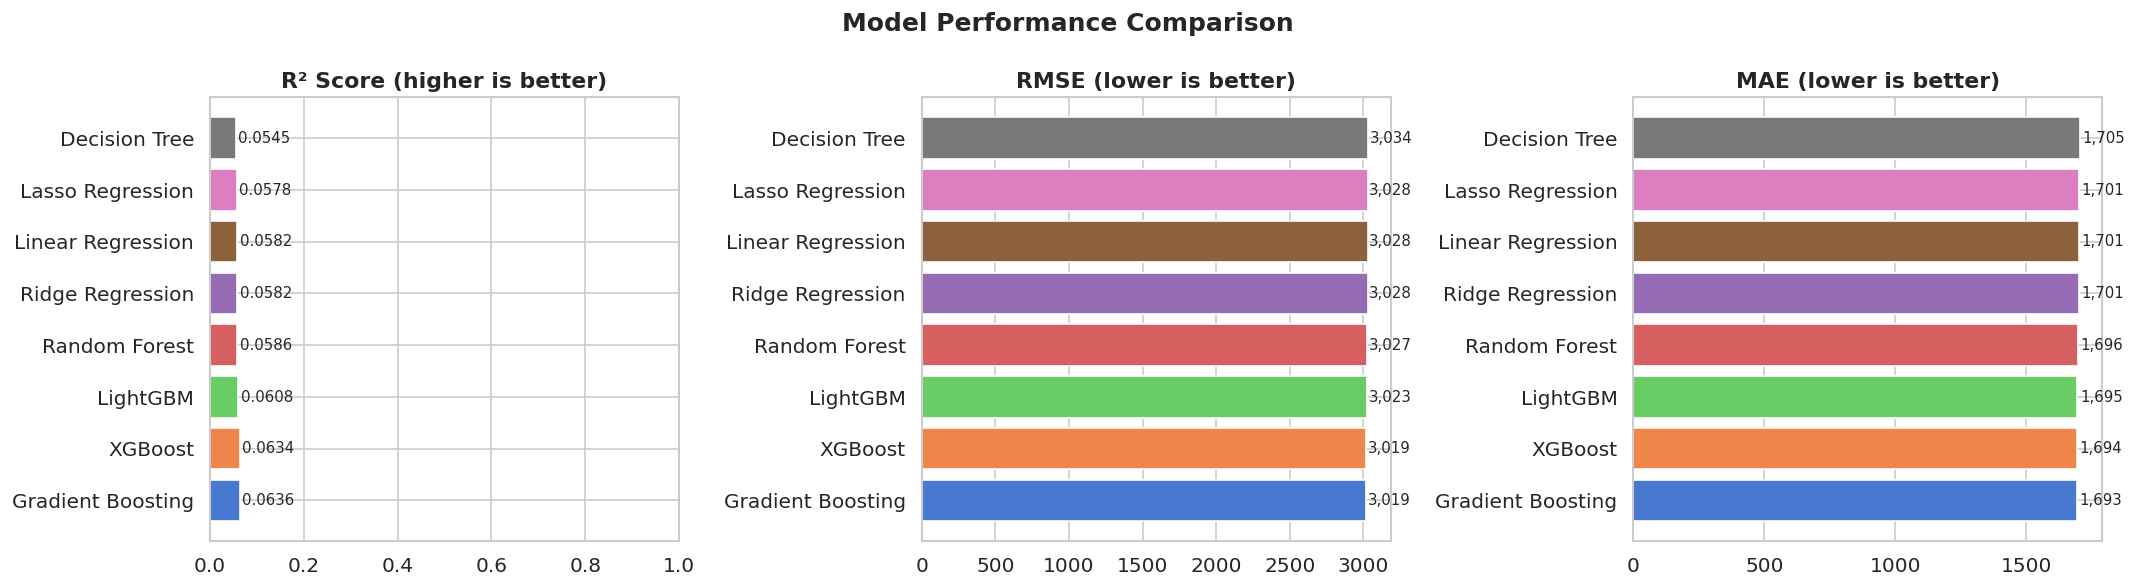

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df['Model']
palette = sns.color_palette('muted', len(models))

# R2
bars = axes[0].barh(models, results_df['R2'], color=palette)
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, results_df['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars = axes[1].barh(models, results_df['RMSE'], color=palette)
axes[1].set_title('RMSE (lower is better)')
for bar, val in zip(bars, results_df['RMSE']):
    axes[1].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

# MAE
bars = axes[2].barh(models, results_df['MAE'], color=palette)
axes[2].set_title('MAE (lower is better)')
for bar, val in zip(bars, results_df['MAE']):
    axes[2].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', bbox_inches='tight')
plt.show()

<a id='13'></a>
## 12. Save Models & Results

In [19]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Results table
results_df.to_csv('../data/processed/model_results.csv', index=False)

# Best model
best_model_name = best_row['Model'].lower().replace(' ', '_')
best_model_obj  = joblib.load(f'../models/{best_model_name}.pkl')
joblib.dump(best_model_obj, '../models/best_model.pkl')

print(' All models and results saved.')
print(f'   Best model → ../models/best_model.pkl ({best_row["Model"]})')
print(f'   Results    → ../data/processed/model_results.csv')
print('\n  Proceed to Notebook 4 — Model Comparison & SHAP')

 All models and results saved.
   Best model → ../models/best_model.pkl (Gradient Boosting)
   Results    → ../data/processed/model_results.csv

  Proceed to Notebook 4 — Model Comparison & SHAP


In [20]:
from google.colab import files

files.download('../data/processed/model_results.csv')
files.download('../models/linear_regression.pkl')
files.download('../models/ridge.pkl')
files.download('../models/lasso.pkl')
files.download('../models/decision_tree.pkl')
files.download('../models/random_forest.pkl')
files.download('../models/gradient_boosting.pkl')
files.download('../models/xgboost.pkl')
files.download('../models/lightgbm.pkl')
files.download('../models/best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>